# Taller 04: Descubriendo Patrones Musicales con Spotify

## 1. Descripción del Caso
Imagina que trabajas como Data Scientist en una plataforma de streaming musical emergente. El equipo de producto quiere mejorar el sistema de recomendación, pero no tienen etiquetas claras para ciertos tipos de canciones.

Te entregan este conjunto de datos sobre 999 canciones y sus caracteristicas https://www.kaggle.com/datasets/glowstudygram/spotify-songs-and-artists-dataset

El objetivo de la actividad es usar algoritmos de agrupamiento (Clustering) para agrupar las canciones más populares del 2023 basándote únicamente en sus características de audio, ignorando el género o el artista. Luego, deberás interpretar qué representa cada grupo.

## 2. Objetivos de Aprendizaje
* Limpieza de datos.
* Estandarización de variables.
* Reducción de dimensionalidad (PCA).
* Clustering (K-Means o DBScan).
* Interpretación de resultados.

### Bloque 1: Configuración y Carga de Datos
Importa las librerías necesarias y carga el dataset.

In [181]:
import pandas as pd
import numpy as np
from pathlib import Path

In [182]:

csv_path = Path('./dataset') 
spotify_df = pd.read_csv(csv_path/ 'spotifydataset.csv')
spotify_df.head()

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [183]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   object 
 2   genres             837 non-null    object 
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   object 
 6   track_name         1000 non-null   object 
 7   album_name         1000 non-null   object 
 8   release_date       1000 non-null   object 
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 n

In [184]:
spotify_df.describe()

,Unnamed: 0,followers,artist_popularity,duration_ms,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,1.150655e+07,59.429000,212368.619000,59.429000,0.611430,0.660562,5.243000,-7.160373,0.613000,0.091402,0.265840,0.074700,0.188810,0.516641,122.143448
std,288.819436,2.293890e+07,23.884963,65706.472572,23.884963,0.167246,0.207568,3.613725,4.479642,0.487307,0.090441,0.288895,0.225472,0.145454,0.232896,28.053658
min,0.000000,2.000000e+00,0.000000,51680.000000,0.000000,0.069000,0.003540,0.000000,-39.482000,0.000000,0.023200,0.000005,0.000000,0.026000,0.032600,49.305000
25%,249.750000,1.038784e+06,57.000000,173083.000000,57.000000,0.505500,0.539500,2.000000,-8.334250,0.000000,0.037975,0.028325,0.000000,0.095700,0.343500,99.983500
50%,499.500000,3.923159e+06,67.000000,204382.500000,67.000000,0.634000,0.680500,5.000000,-5.943500,1.000000,0.054800,0.152500,0.000004,0.129000,0.522000,122.073500
75%,749.250000,1.142132e+07,74.000000,244192.750000,74.000000,0.728250,0.820000,9.000000,-4.582500,1.000000,0.106000,0.416250,0.000586,0.246500,0.686250,138.667250
max,999.000000,1.194287e+08,92.000000,707160.000000,92.000000,0.964000,0.998000,11.000000,0.273000,1.000000,0.874000,0.996000,0.972000,0.984000,0.973000,201.776000


In [185]:
spotify_df.isnull().sum()

Unnamed: 0             0
artist_name            0
genres               163
followers              0
artist_popularity      0
artist_url             0
track_name             0
album_name             0
release_date           0
duration_ms            0
explicit               0
track_popularity       0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
dtype: int64

### Bloque 2: Limpieza y Preparación
Se debe trabajar solamente con las columnas que describen como es la canción en terminos auditivos:

- track_popularity
- danceability
- energy
- key
- loudness
- mode
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo

No se deben usar columnas como el artista o genero para evitar sesgos en la agrupación

Datafrmae con las columnas necesarias o features

In [186]:
feat_df = spotify_df[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']]
feat_df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.645,0.646,-8.334,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,0.795,0.630,-5.854,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,0.506,0.362,-9.480,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,0.650,0.825,-4.645,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,0.787,0.775,-6.614,0.0548,0.1900,0.000065,0.1130,0.787,118.998


### Bloque 3: Reducción de Dimensionalidad (PCA)
Reduce los datos a 2 componentes principales para poder visualizarlos en un gráfico 2D.

- PCA realiza la reducción de dimensionalidad.
- StandardScaler normaliza los datos antes del PCA.

Importar librerías sklearn

In [187]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

Paso 1: Crear el escalador

Aquí se crea un objeto que sabe cómo transformar los datos para que cada variable tenga:


- Media = 0
- Desviación estándar = 1

In [189]:
scaler = StandardScaler()

Paso 2: Ajustar y transformar los datos

fit()

Calcula para cada columna:

La media (mean)
La desviación estándar (std)

In [190]:
data_scaled = scaler.fit_transform(feat_df)

In [191]:
print(feat_df.shape)

(1000, 9)


Reduce mis 9 variables originales a solamente 2 componentes principales con PCA.

In [192]:
pca = PCA(n_components=2)

In [193]:
pca_result = pca.fit_transform(data_scaled)

In [194]:
print(pca_result.shape)

(1000, 2)


In [195]:
print(pca_result[:5])

[[-0.11601143 -0.17958553]
 [ 0.30676432  0.93946987]
 [-1.96639019  0.59406128]
 [ 1.12942024  0.0149306 ]
 [ 0.99117179  1.13524462]]


In [196]:
pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2']
)

print(pca_df.head())

        PC1       PC2
0 -0.116011 -0.179586
1  0.306764  0.939470
2 -1.966390  0.594061
3  1.129420  0.014931
4  0.991172  1.135245


Ver cuánta información conservan esos componentes:

In [197]:
print(pca.explained_variance_ratio_)

[0.32469935 0.16270942]


El PCA redujo las 9 características musicales a 2 componentes principales. El primer componente explica el 32% de la variabilidad de los datos y el segundo componente el 16%. En conjunto, ambos componentes capturan aproximadamente el 48% de la información original, permitiendo una visualización bidimensional de los datos aunque con cierta pérdida de información.

In [198]:
print(sum(pca.explained_variance_ratio_))

0.4874087696957211


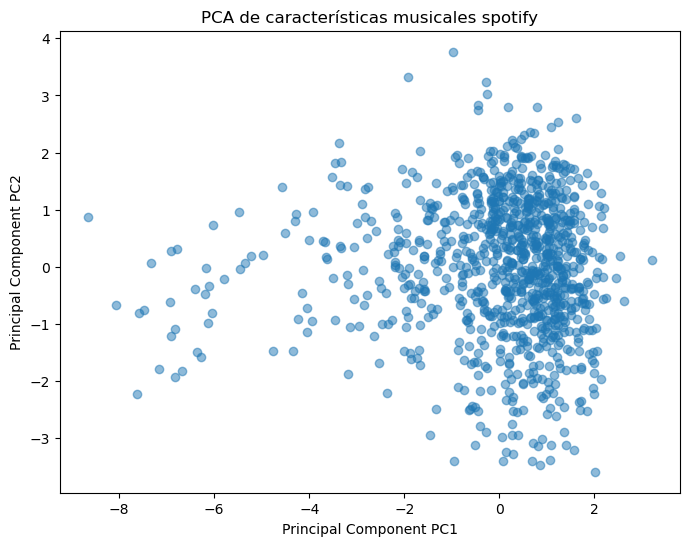

In [199]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.5
)

plt.xlabel('Principal Component PC1')
plt.ylabel('Principal Component PC2')
plt.title('PCA de características musicales spotify')
plt.show()

Existe una gran concentración de canciones en el centro
La mayoría de los puntos están entre aproximadamente:
 - PC1: -1 a 2
 - PC2: -2 a 2

Esto indica que muchas canciones tienen características musicales relativamente similares.

Hay una cola hacia la izquierda

Se observan varias canciones con valores de PC1 muy negativos (-8 a -4).

Estas canciones son bastante diferentes del grupo principal en términos de las características musicales originales (danceability, energy, acousticness, etc.).

No se observan clusters claramente separados

Los puntos forman una nube continua.
No parece haber grupos naturales muy definidos únicamente con los dos primeros componentes.
Hay algunos outliers
Canciones aisladas en los extremos de PC1 y PC2.

Podrían representar canciones con características poco comunes dentro del dataset.

Interpretación
PC1 explica 32% de la variabilidad
PC2 explica 16%

In [200]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feat_df.columns
)

print(loadings)

                       PC1       PC2
danceability      0.250210  0.592839
energy            0.494364 -0.252836
loudness          0.508321 -0.101058
speechiness       0.109451  0.189102
acousticness     -0.439296  0.242152
instrumentalness -0.370961 -0.203182
liveness          0.146913 -0.288522
valence           0.247257  0.469789
tempo             0.096523 -0.367120


### Bloque 4: Modelado (Usa K-Means o DB Scan para generar los clusters)

## Elegir K con el método del codo

K-means necesita que le digamos cuántos grupos (K) queremos de antemano. El **método del codo** nos ayuda a elegir un buen valor:

1. Probamos K-means con distintos valores de K (por ejemplo, de 1 a 10)
2. Para cada K, medimos la **inercia**: qué tan "compactos" quedan los grupos (suma de distancias al cuadrado entre cada punto y su centroide)
3. A medida que K crece, la inercia siempre baja — pero llega un punto donde bajar más ya no mejora mucho
4. Ese punto de "quiebre" en la curva (parece un codo) es un buen valor de K

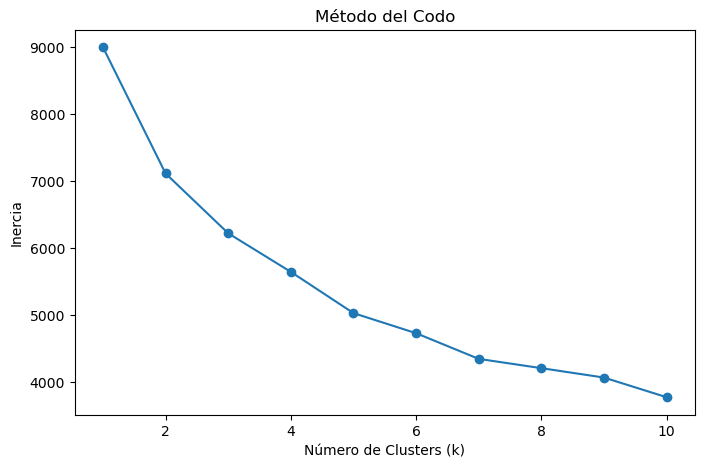

In [201]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

**Cómo leer esta gráfica:** busca el punto donde la curva deja de bajar bruscamente y empieza a "aplanarse". Ese es tu "codo". 

## Entrenar K-means con el K elegido

Entrenamos el modelo final y le pedimos que asigne cada canción a uno de los K grupos.

In [202]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

In [203]:
df_train= spotify_df.copy()
df_train['Cluster'] = clusters

In [204]:
df_train[['artist_name', 'track_name','genres', 'album_name', 'Cluster']].head(10)

,artist_name,track_name,genres,album_name,Cluster
0,Ariana Grande,we can't be friends (wait for your love),pop,eternal sunshine,0
1,Ariana Grande,the boy is mine,pop,eternal sunshine,0
2,Ariana Grande,intro (end of the world),pop,eternal sunshine,4
3,Ariana Grande,Save Your Tears (Remix) (with Ariana Grande) -...,pop,After Hours (Deluxe),0
4,Ariana Grande,"yes, and?",pop,eternal sunshine,0
5,Ariana Grande,One Last Time,pop,My Everything - Deluxe,2
6,Ariana Grande,Die For You (with Ariana Grande) - Remix,pop,Starboy (Deluxe),0
7,Ariana Grande,7 rings,pop,"thank u, next",3
8,Ariana Grande,Dangerous Woman,pop,Dangerous Woman,2
9,Ariana Grande,Into You,pop,Dangerous Woman,2


In [205]:
# ¿Cuántas canciones cayeron en cada cluster?
df_train['Cluster'].value_counts().sort_index()

Cluster
0    379
1     54
2    331
3     99
4    137
Name: count, dtype: int64

Interpretar los clusters

Solo agrupó canciones con características de audio parecidas.

In [206]:
# Promedio de cada característica por cluster (en la escala original, sin escalar)
cluster_profile = df_train.groupby('Cluster')[feat_df.columns].mean().round(3)
cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,
0,0.728,0.680,-6.189,0.069,0.229,0.014,0.148,0.669,113.826
1,0.433,0.279,-19.573,0.052,0.779,0.840,0.117,0.316,112.683
2,0.526,0.808,-5.050,0.076,0.080,0.057,0.261,0.435,136.557
3,0.695,0.645,-7.423,0.313,0.266,0.007,0.208,0.547,122.988
4,0.505,0.412,-9.864,0.048,0.616,0.032,0.142,0.350,113.448


### Bloque 4b: DBSCAN como alternativa

A diferencia de K-means, DBSCAN no necesita que le digamos cuántos grupos queremos. En cambio, necesita dos parámetros:

- **eps**: el radio de vecindad (¿qué tan cerca tienen que estar dos canciones para considerarse "vecinas"?)
- **min_samples**: cuántos vecinos mínimos necesita un punto para ser un "núcleo"

DBSCAN puede marcar puntos como **ruido** (etiqueta `-1`) — canciones que no encajan bien en ningún grupo denso.

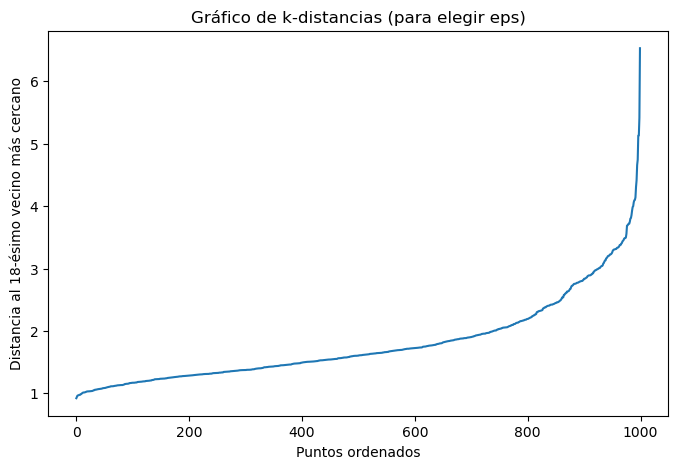

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# estimar un buen valor de eps con el "gráfico de k-distancias"
# Regla común: min_samples = 2 * número de dimensiones
min_samples = 18

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(data_scaled)
distances, indices = neighbors_fit.kneighbors(data_scaled)

# Ordenamos las distancias al k-ésimo vecino más cercano
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_dist)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}-ésimo vecino más cercano")
plt.title("Gráfico de k-distancias (para elegir eps)")
plt.show()

**Cómo leer esta gráfica:** busca el "codo" donde la curva sube bruscamente — ese valor en el eje Y es un buen candidato para `eps`. En este dataset la curva sube de forma bastante gradual (sin un codo muy marcado), lo que ya es una pista de que la densidad de los datos es bastante uniforme — no hay zonas súper densas separadas de zonas vacías.

In [169]:
# Paso 2: probar varios valores de eps y ver cómo cambia el resultado
for eps in [1.0, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0]:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(data_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps:>4} -> clusters={n_clusters}, ruido={n_noise} ({n_noise/len(labels)*100:.1f}%)")

eps= 1.0 -> clusters=1, ruido=906 (90.6%)
eps= 1.5 -> clusters=1, ruido=327 (32.7%)
eps= 1.8 -> clusters=1, ruido=178 (17.8%)
eps= 2.0 -> clusters=1, ruido=134 (13.4%)
eps= 2.2 -> clusters=1, ruido=106 (10.6%)
eps= 2.5 -> clusters=2, ruido=58 (5.8%)
eps= 3.0 -> clusters=1, ruido=8 (0.8%)


**Qué observar en esta tabla:**

- Con `eps` chico (1.0-1.5): casi todo es ruido. El radio es muy pequeño, casi nada tiene suficientes vecinos.
- Con `eps` grande (2.0-3.0): casi todo cae en **un solo cluster gigante** + algo de ruido.
- En ningún punto aparecen "varios clusters medianos" como con K-means.

**¿Por qué pasa esto?** DBSCAN necesita zonas de alta densidad separadas por "espacios vacíos". Si recuerdas el gráfico de PCA, viste que los datos forman **una nube continua** sin separaciones claras — eso es justo lo que hace que DBSCAN vea "todo es una sola zona densa" en lugar de varios grupos. Esto NO es un error: es DBSCAN diciéndote algo real sobre la forma de tus datos.

In [208]:
# nos quedamos con un eps que produzca un cluster principal + ruido razonable
eps = 2.0  # ~13% de ruido

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
clusters_dbscan = dbscan.fit_predict(data_scaled)

df_train_dbscan= spotify_df.copy()
df_train_dbscan['Cluster_DBSCAN'] = clusters_dbscan

n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)
print(f"Clusters: {n_clusters} | Ruido: {n_noise} ({n_noise/len(clusters_dbscan)*100:.1f}%)")
print(df_train_dbscan['Cluster_DBSCAN'].value_counts().sort_index())


Clusters: 1 | Ruido: 134 (13.4%)
Cluster_DBSCAN
-1    134
 0    866
Name: count, dtype: int64


### Bloque 5: Visualización y Análisis
Genera visualizaciones que permitan interpretar qué significa cada grupo.

### K-means

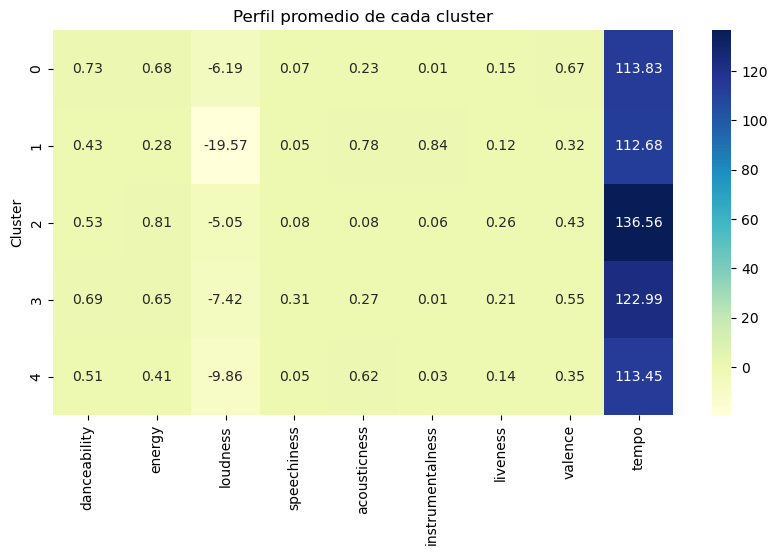

In [166]:
# Visualizamos el perfil de cada cluster con un heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Perfil promedio de cada cluster")
plt.ylabel("Cluster")
plt.show()

**Cómo interpretar el heatmap:** compara los valores de cada fila (cluster). Por ejemplo:

- Un cluster con `energy` y `loudness` altos y `acousticness` bajo → canciones "fuertes", probablemente rock/electrónica/pop energético
- Un cluster con `acousticness` alto y `energy` bajo → canciones acústicas/calmadas
- Un cluster con `danceability` y `valence` altos → canciones alegres y bailables
- Un cluster con `instrumentalness` alto → canciones sin voz o predominantemente instrumentales

In [167]:
# Ejemplo: ver algunas canciones representativas de cada cluster
for c in sorted(df_train['Cluster'].unique()):
    print(f"\n--- Cluster {c} ({(df_train['Cluster'] == c).sum()} canciones) ---")
    print(df_train[df_train['Cluster'] == c][['artist_name', 'track_name']].head(10).to_string(index=False))


--- Cluster 0 (379 canciones) ---
  artist_name                                                 track_name
Ariana Grande                   we can't be friends (wait for your love)
Ariana Grande                                            the boy is mine
Ariana Grande Save Your Tears (Remix) (with Ariana Grande) - Bonus Track
Ariana Grande                                                  yes, and?
Ariana Grande                   Die For You (with Ariana Grande) - Remix
        Adele                                       Set Fire to the Rain
        Adele                                        Rolling in the Deep
   A$AP Rocky                                                   Sundress
   A$AP Rocky                  Praise The Lord (Da Shine) (feat. Skepta)
   A$AP Rocky                                              Fashion Killa

--- Cluster 1 (54 canciones) ---
   artist_name              track_name
        Alex G               Treehouse
        Alex G                  Change
        Ale

dbscan

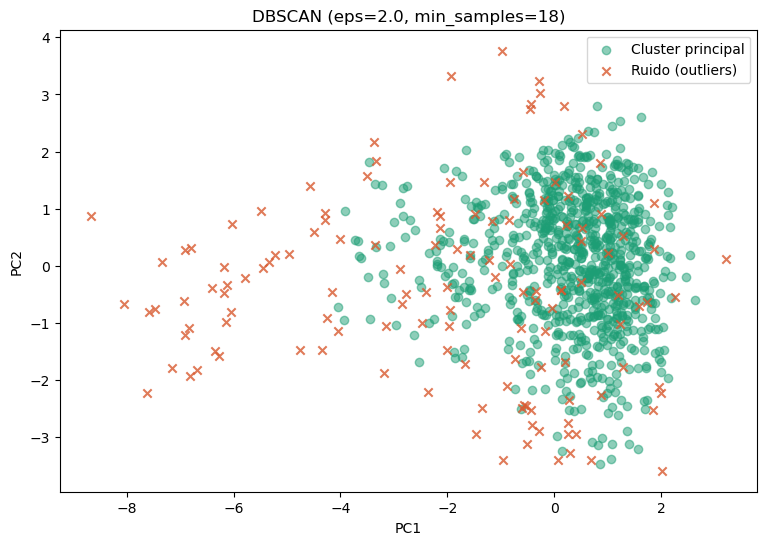

In [209]:
# Paso 4: visualizar el resultado con PCA — destacando el ruido
plt.figure(figsize=(9,6))
mask_noise = clusters_dbscan == -1

plt.scatter(pca_result[~mask_noise, 0], pca_result[~mask_noise, 1],
            c='#1D9E75', alpha=0.5, label='Cluster principal')
plt.scatter(pca_result[mask_noise, 0], pca_result[mask_noise, 1],
            c='#D85A30', marker='x', alpha=0.8, label='Ruido (outliers)')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN (eps={eps}, min_samples={min_samples})')
plt.legend()
plt.show()

### Conclusiones

Plantear 3 conclusiones propias basadas en los resultados obtenidos

### Conclusión 1:  Clustering K-means

Los clusters reflejan estilos musicales reconocibles, no géneros etiquetados. A pesar de que el modelo nunca recibió información sobre artista o género, los 5 grupos encontrados corresponden a estilos musicales identificables: el Cluster 1 agrupa sonidos acústicos y experimentales (Aphex Twin, Alex G), el Cluster 3 agrupa canciones de rap/hip-hop con alto speechiness (A Boogie Wit da Hoodie, colaboraciones con Drake y Kendrick Lamar), y el Cluster 4 agrupa baladas emotivas de piano y voz (Adele). Esto demuestra que las características de audio por sí solas contienen suficiente información para diferenciar tipos de música

### Conclusión 2:  Clustering DBSCAN

Sin saber nada de los clusters anteriores, "redescubrió" el mismo grupo raro que ya habíamos visto con K-means y PCA. Cuando exploramos PCA en DBSCAN, vimos que los datos forman una nube bastante continua, sin separaciones claras — eso ya era una pista de que no habría "islas" densas bien definidas. Confirmamos esa pista con DBSCAN: por más que ajustamos eps, nunca aparecieron varios grupos medianos, solo un cluster gigante más un porcentaje de "ruido". Pero lo más interesante es que ese ruido (13.4% de las canciones) coincide casi perfectamente con el Cluster 1 de K-means — el grupo acústico/experimental de Aphex Twin y Alex G. Tres herramientas distintas (PCA, K-means y DBSCAN), cada una mirando los datos de forma diferente, llegaron a la misma conclusión: ese grupo de canciones es genuinamente atípico dentro del dataset, mientras que el resto forma un continuo de estilos pop/rock que se mezclan entre sí sin fronteras claras.

### Conclusión 3 K-means

Lo "mainstream" domina el dataset. Los dos clusters más grandes (0 y 2) juntan más del 70% de las canciones, y ambos son ese sonido pop/dance/rock con mucha energía típico de las listas de popularidad. En cambio, el sonido más acústico/experimental del Cluster 1 es el más chico (solo 54 canciones), lo que sugiere que ese estilo es más una excepción que la regla entre las canciones populares de 2023.